In [415]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### Default Technology Cost DataBase:

In [416]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [417]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

- all capital cost inputs are annualized

In [418]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Data Inputs

In [419]:
# Get the directory of the current script
current_dir = os.getcwd()

# Build file paths relative to the script location
pv_file = os.path.join(current_dir, "pv_optimal.csv")
wind_file = os.path.join(current_dir, "onshore_wind_1979-2017.csv")
dk1_file = os.path.join(current_dir, "2017_DK1_SpotSprice_Load.xlsx")
# dk1_file = os.path.join(current_dir, "DK1_2017.csv")  # optional alternative

# Read the files
solar_pv_data = pd.read_csv(pv_file, sep=";")
onshore_wind_data = pd.read_csv(wind_file, sep=";")
DK1_data_2017 = pd.read_excel(dk1_file)

In [420]:
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

In [421]:
gas_price_data.head()

,GasDay,EEXSpotIndexEUR_MWh,EEXWithinDayEUR_MWh,ExchangeRateEUR_DKK,SalesPriceDKK_kWh,PurchasePriceDKK_kWh,NeutralGasPriceDKK_kWh,EEXHighestPricePurchaseDKK_kWh,EEXLowestPriceSaleDKK_kWh,MarginalSalePriceDKK_kWh,MarginalPurchasePriceDKK_kWh,THEPriceDKK_kWh
GasDay,,,,,,,,,,,,
2022-10-01,2022-10-01,168.168,165.000,743.65,1.2332,1.2209,1.2270,NaN,NaN,1.2332,1.2209,1.2239
2022-10-02,2022-10-02,168.168,157.742,743.65,1.1789,1.1672,1.1730,NaN,NaN,1.1789,1.1672,1.2239
2022-10-03,2022-10-03,167.210,141.581,743.66,1.0581,1.0476,1.0529,NaN,NaN,1.0581,1.0476,1.2203
2022-10-04,2022-10-04,147.942,117.112,743.74,0.8754,0.8667,0.8710,NaN,0.3719,0.8754,0.3719,1.0478
2022-10-05,2022-10-05,119.772,82.244,743.88,0.6149,0.6087,0.6118,NaN,NaN,0.6149,0.6087,0.7978


<Axes: >

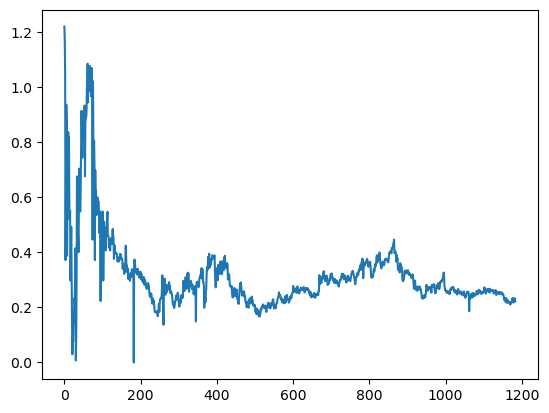

In [422]:
gas_price_data = pd.read_excel(gas_file);
gas_price_data["MarginalPurchasePriceDKK_kWh"].plot() # DKK/KWh


In [423]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [424]:
EUR_DKK_exchnagerate =(gas_price_hourly["ExchangeRateEUR_DKK"]/100)

<Axes: xlabel='GasDay'>

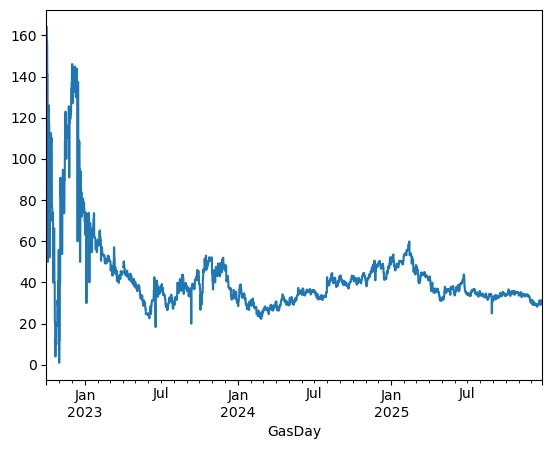

In [425]:
((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchnagerate)*1000).plot() # EUR/MWh

In [426]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchnagerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] 

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [427]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])

## Correct Spot Price Data

In [428]:
elspotprices = pd.read_excel("Elspotprices2021_2025.xlsx", index_col=0, parse_dates=True) # EUR/MWh
elspotprices.head()

,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
HourUTC,,,,
2021-12-28 23:00:00,2021-12-29 00:00:00,DK1,833.280029,112.059998
2021-12-29 00:00:00,2021-12-29 01:00:00,DK1,693.559998,93.269997
2021-12-29 01:00:00,2021-12-29 02:00:00,DK1,701.739990,94.370003
2021-12-29 02:00:00,2021-12-29 03:00:00,DK1,675.340027,90.820000
2021-12-29 03:00:00,2021-12-29 04:00:00,DK1,699.059998,94.010002


<Axes: xlabel='HourUTC'>

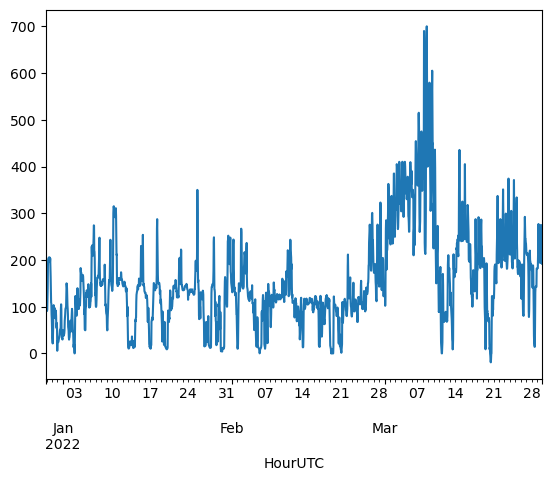

In [429]:
elspotprices["SpotPriceEUR"]["2021-12-28":"2022-3-29"].plot()

https://www.renewables.ninja/

In [430]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')

# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)

# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)

# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()

# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


<Axes: xlabel='utc_time'>

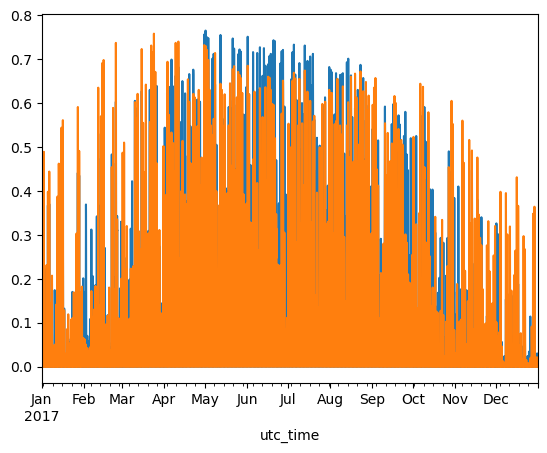

In [431]:
# Comparison between Solar Data Source
PV_data["DK01"]["2017-01-01":"2017-12-31"].plot()
solar_pv_data["DNK"]["2017-01-01":"2017-12-31"].plot()

In [432]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


<Axes: xlabel='utc_time'>

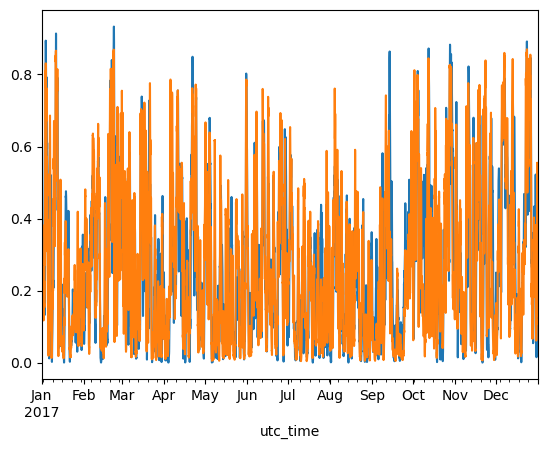

In [433]:
# Comparison between Wind data Source
OnshoreWind_Data["DK01"]["2017-01-01":"2017-12-31"].plot()
onshore_wind_data["DNK"]["2017-01-01":"2017-12-31"].plot()

### Spot Price Data

In [434]:
DKK_Euro = 7.468  #https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-dkk.en.html

el_transmission_tariff = 4.3 / 100 * 1000 / DKK_Euro   # from energinet inputs in Ore/kWh DKK/MWh, bef 7.5
el_system_tariff = 7.2 / 100 * 1000 / DKK_Euro   # bef 5.1
el_afgift =  0.8 / 100 * 1000 / DKK_Euro         # bef 76.1 https://skm.dk/tal-og-metode/satser/satser-og-beloebsgraenser-i-lovgivningen/elafgiftsloven  https://elberegner.dk/guides/elafgift/
 
# DSO Tariff -  for 60/10kV transformer (A_low customer) #Staring from January 2026 https://n1.dk/elnetkunder/kommende-priser
el_net_tariff_low = 1.54  / 100 * 1000 / DKK_Euro   # Ore/kWh to eur/MWh
el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro
el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro

VAT = 0.25 # 25 % VAT (Value Added Tax)

In [435]:
from types import SimpleNamespace

p = SimpleNamespace(

    # Model year (for defining summer/winter periods)
    En_price_year = 2017,

    # Full analysis period
    start_date = "2017-01-01",
    end_date   = "2018-01-01",

    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)

# 2. PRICE CALCULATION FUNCTION
# ============================================================
def build_electricity_grid_price_w_tariff(Elspotprices):
    """
    Inputs:
        Elspotprices : pd.Series indexed by DatetimeIndex (HourUTC)
    Output:
        (final_grid_buy_price, grid_sell_price)
    """
    # ---- Base buy price (fixed tariffs only) ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # ---- Grid selling price ----
    sell_price = -Elspotprices + p.el_tariff_sell

    # Use timestamps directly from your Series
    hours = Elspotprices.index

    # ---- SUMMER ----
    summer_start = pd.Timestamp(f"{p.En_price_year}-04-01 00:00", tz=hours.tz)
    summer_end   = pd.Timestamp(f"{p.En_price_year}-10-01 00:00", tz=hours.tz)

    summer = hours[(hours >= summer_start) & (hours < summer_end)]

    # ---- WINTER = all other hours ----
    winter = hours.difference(summer)

    # Remove Feb 29
    winter = winter[~((winter.month == 2) & (winter.day == 29))]

    # ---- Tariff rules ----
    peak_hours          = range(7, 22)     # 06–21
    high_wd_winter      = range(22, 25)    # 21–23
    high_we_winter      = range(7, 25)     # 06–23
    high_wd_summer      = range(7, 25)     # 06–23

    # ---- Tariff decision function ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour

        if h in winter:
            # WINTER
            if wd >= 5:  # weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low

        else:
            # SUMMER
            if wd >= 5:  # weekend
                return p.el_net_tariff_low
            else:
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # ---- Hourly tariff series ----
    tariffs = pd.Series({h: tariff(h) for h in hours})

    # ---- Final buy price ----
    final_price = base_price + tariffs

    return final_price, sell_price

In [436]:
Elspotprices = DK1_data_2017["DK1_EUR/MWh"]

# Compute grid prices
grid_buy_price, grid_sell_price = build_electricity_grid_price_w_tariff(Elspotprices)

<Axes: xlabel='HourUTC'>

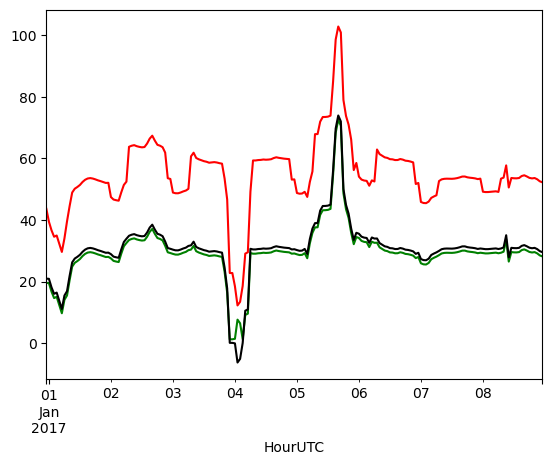

In [437]:
grid_buy_price["2016-12-31 23:00:00":"2017-01-08 23:00:00"].plot(color = "red")

#---- Similar Magnitudes, just the tariffs added-----------------
abs(grid_sell_price["2016-12-31 23:00:00":"2017-01-08 23:00:00"]).plot(color = "green")
Elspotprices["2016-12-31 23:00:00":"2017-01-08 23:00:00"].plot(color = "black")


In [438]:
costs.at["battery storage", "capital_cost"]/(5000*0.9)

2.8794729710597164

### Initialisation of Model and Components

In [439]:
import pandas as pd

def get_time_period(start='2017-01-01', end='2017-12-31', freq='h', tz_naive=True):
    """
    Generates a pandas DatetimeIndex for a specified period.
    
    Args:
        start (str): Start date/time (e.g., '2017-01-01' or '2017-01-01 00:00Z')
        end (str): End date/time
        freq (str): Frequency (default 'h' for hourly)
        tz_naive (bool): If True, removes timezone info (localized to None)
        
    Returns:
        pd.DatetimeIndex
    """
    # Create the range
    dr = pd.date_range(start=start, end=end, freq=freq)
    
    # Strip timezone if requested
    if tz_naive and dr.tz is not None:
        dr = dr.tz_localize(None)
    elif tz_naive and dr.tz is None:
        # Even if not localized, ensure it's naive if strings had offsets
        dr = dr.tz_localize(None)
        
    return dr

In [440]:
# 1. Replicating your 2017 logic
time_period_2017 = get_time_period('2017-01-01 00:00Z', '2017-12-30 22:00Z', freq = "h")

time_period_2017

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2017-12-30 13:00:00', '2017-12-30 14:00:00',
               '2017-12-30 15:00:00', '2017-12-30 16:00:00',
               '2017-12-30 17:00:00', '2017-12-30 18:00:00',
               '2017-12-30 19:00:00', '2017-12-30 20:00:00',
               '2017-12-30 21:00:00', '2017-12-30 22:00:00'],
              dtype='datetime64[ns]', length=8735, freq=None)

In [441]:
p = SimpleNamespace(
    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)

In [442]:
import pandas as pd

def build_electricity_grid_price_w_tariff(Elspotprices,p ,year):
    """
    Calculates prices for a specific YEAR by filtering the input data.
    """
    # 1. ---- SELECT THE YEAR ----
    # This filters the index so we only calculate for the year we want
    year_str = str(year)
    Elspotprices = Elspotprices[year_str].copy()
    
    if Elspotprices.empty:
        raise ValueError(f"No data available in Elspotprices for the year {year}")

    # 2. ---- BASE CALCULATIONS ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # Grid selling price (revenue is often positive in PyPSA, 
    # remove the minus if your bus logic requires it)
    sell_price = -Elspotprices + p.el_tariff_sell

    hours = Elspotprices.index

    # 3. ---- SEASONAL DEFINITIONS ----
    # Use the 'year' argument to define the periods correctly
    summer_start = pd.Timestamp(year=year, month=4, day=1, hour=0).tz_localize(hours.tz)
    summer_end   = pd.Timestamp(year=year, month=10, day=1, hour=0).tz_localize(hours.tz)

    # Create boolean masks for summer/winter (much faster than .difference)
    is_summer = (hours >= summer_start) & (hours < summer_end)
    is_winter = ~is_summer

    # 4. ---- TARIFF RULES ----
    # Radius/Cerius standard Danish time-of-use windows
    peak_hours      = range(17, 21)    # 17–21 (Cooking peak)
    high_wd_winter  = range(6, 24)     # 06-17 and 21-24 are high (excluding peak)
    high_we_winter  = range(6, 24)     # 06–24
    high_wd_summer  = range(6, 24)     # 06–24

    # 5. ---- TARIFF DECISION LOGIC ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour
        
        if is_winter[hours.get_loc(h)]:
            # WINTER
            if wd >= 5:  # Weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:        # Weekday
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low
        else:
            # SUMMER
            if wd >= 5:  # Weekend
                return p.el_net_tariff_low
            else:        # Weekday
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # 6. ---- APPLY AND RETURN ----
    tariffs = pd.Series({h: tariff(h) for h in hours})
    buy_price = base_price + tariffs

    return buy_price, sell_price

In [443]:
buy_price22, sell_price22 = build_electricity_grid_price_w_tariff(elspotprices["SpotPriceEUR"],p,year = 2022)

In [444]:
elspotprices["SpotPriceEUR"]["2022"]

HourUTC
2022-01-01 00:00:00    41.330002
2022-01-01 01:00:00    43.220001
2022-01-01 02:00:00    45.459999
2022-01-01 03:00:00    37.669998
2022-01-01 04:00:00    39.700001
                         ...    
2022-12-31 19:00:00    40.500000
2022-12-31 20:00:00    14.890000
2022-12-31 21:00:00     9.940000
2022-12-31 22:00:00     4.840000
2022-12-31 23:00:00     2.010000
Name: SpotPriceEUR, Length: 8760, dtype: float64

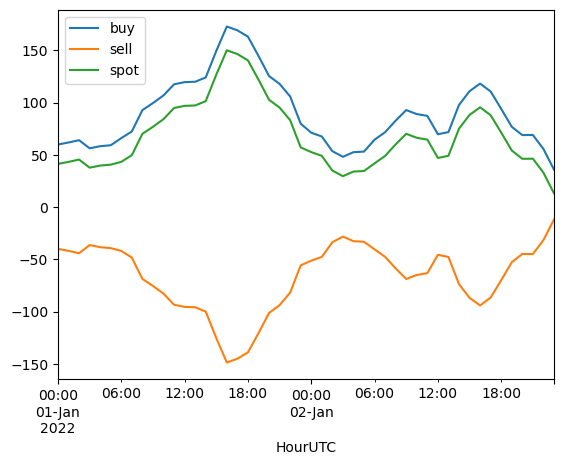

In [445]:
buy_price22[0:24*2].plot(label = "buy")
sell_price22[0:24*2].plot(label = "sell")
elspotprices["SpotPriceEUR"]["2022"][0:24*2].plot(label = "spot")
plt.legend()

In [446]:
time_period = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
time_period

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8760, freq=None)

- we only have full dataset years for 2023 onwards

In [447]:
"Spot Price Data";
price_import23, price_export23 = build_electricity_grid_price_w_tariff(elspotprices["SpotPriceEUR"],p,year = 2023)

"Capacity Factor Wind";
CF_w23 = OnshoreWind_Data["DK01"]["2023"]

"Capacity Factor Solar";
CF_s23 = PV_data["DK01"]["2023"]

"Natural Gas Price";
NG_price23 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2023"]


In [448]:
price_export23

HourUTC
2023-01-01 00:00:00    -0.000782
2023-01-01 01:00:00     1.289218
2023-01-01 02:00:00     1.299218
2023-01-01 03:00:00     1.329218
2023-01-01 04:00:00     1.379218
                         ...    
2023-12-31 19:00:00   -33.510781
2023-12-31 20:00:00   -28.220782
2023-12-31 21:00:00   -27.290782
2023-12-31 22:00:00   -25.490783
2023-12-31 23:00:00   -15.610782
Name: SpotPriceEUR, Length: 8760, dtype: float64

In [449]:
price_import23

HourUTC
2023-01-01 00:00:00    19.912405
2023-01-01 01:00:00    18.622405
2023-01-01 02:00:00    18.612405
2023-01-01 03:00:00    18.582405
2023-01-01 04:00:00    18.532405
                         ...    
2023-12-31 19:00:00    57.560058
2023-12-31 20:00:00    52.270059
2023-12-31 21:00:00    51.340059
2023-12-31 22:00:00    49.540060
2023-12-31 23:00:00    39.660059
Length: 8760, dtype: float64

In [450]:
CF_w23

time
2023-01-01 00:00:00    0.429228
2023-01-01 01:00:00    0.464952
2023-01-01 02:00:00    0.535109
2023-01-01 03:00:00    0.660334
2023-01-01 04:00:00    0.663411
                         ...   
2023-12-31 19:00:00    0.553364
2023-12-31 20:00:00    0.501247
2023-12-31 21:00:00    0.439215
2023-12-31 22:00:00    0.379284
2023-12-31 23:00:00    0.296996
Name: DK01, Length: 8760, dtype: float64

In [451]:
CF_s23

time
2023-01-01 00:00:00    0.0
2023-01-01 01:00:00    0.0
2023-01-01 02:00:00    0.0
2023-01-01 03:00:00    0.0
2023-01-01 04:00:00    0.0
                      ... 
2023-12-31 19:00:00    0.0
2023-12-31 20:00:00    0.0
2023-12-31 21:00:00    0.0
2023-12-31 22:00:00    0.0
2023-12-31 23:00:00    0.0
Name: DK01, Length: 8760, dtype: float64

In [452]:
NG_price23

GasDay
2023-01-01 00:00:00    63.215220
2023-01-01 01:00:00    63.215220
2023-01-01 02:00:00    63.215220
2023-01-01 03:00:00    63.215220
2023-01-01 04:00:00    63.215220
                         ...    
2023-12-31 19:00:00    29.706557
2023-12-31 20:00:00    29.706557
2023-12-31 21:00:00    29.706557
2023-12-31 22:00:00    29.706557
2023-12-31 23:00:00    29.706557
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 8760, dtype: float64

<Axes: xlabel='GasDay'>

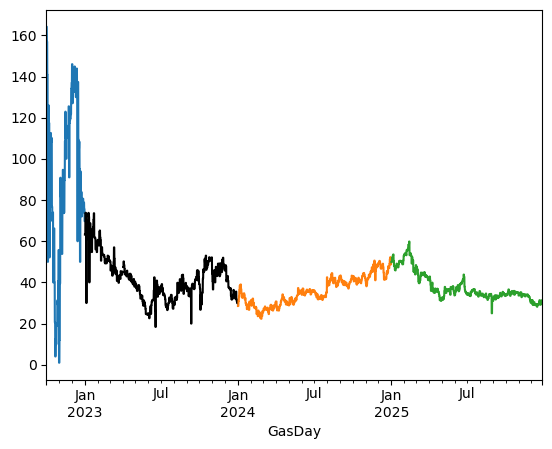

In [453]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price23.plot(color = "black")
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2025"].plot()

In [454]:
def add_carriers(n):
    n.add("Carrier",'electricity grid im')
    n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    n.add("Carrier","Rondo charge")
    n.add("Carrier","Rondo store")
    n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat MT")
    n.add("Carrier","heat boiler")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")

In [455]:
costs.at["solar", "capital_cost"]

51346.82981964593

In [456]:
def add_skive_generators(n,p_PPA):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "EuroWind" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= CF_s23.values, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "EuroWind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= CF_w23.values,
        p_nom = 54)

    #--------------------------------
    # PPA link
    n.add("Link", "PPA",
          bus0="EuroWind",
          bus1="Greenlab",
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=p_PPA)

In [457]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="EuroWind",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="EuroWind",
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

    

In [458]:
# Assuming that EuroWind will do all the balancing and Ancillarly Services and

def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="EuroWind",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 4 h = 88 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [459]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [460]:
# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [461]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

In [462]:
def add_heat_load(n,p_load):
    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_MT",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

In [463]:
def add_NG_boiler(n,CO2tax):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        marginal_cost = NG_price23 + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        capital_cost=5772) 
    

In [464]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", "biomass input,
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="CO2") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="CO2")

In [465]:
#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [632]:
def build_network(P_el,P_heat,CO2_tax1, CO2_tax2,p_import,p_export):
     
    n = pypsa.Network()
    hours = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
    n.set_snapshots(hours)

    add_carriers(n)

    n.add("Bus", "Greenlab", carrier = "electricity")
    n.add("Bus", "EuroWind", carrier = "electricity")
    n.add("Bus", "Grid_Import", carrier = "electricity")
    n.add("Bus", "Grid_Export", carrier = "electricity")
    
    n.add("Bus", "Heat_Exchanger_Bus", carrier = "heat")
    n.add("Bus","TES_Rondo", carrier = "heat")
    n.add("Bus", "Heat_MT", carrier = "heat")

    n.add("Bus", "NG", carrier = "gas")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="CO2")
    n.add("Bus", "biochar sequestration", carrier="CO2")


    add_battery(n,P_nom = 22, max_t = 4, cyclic_operation = True)
    add_skive_generators(n, p_PPA  = 90)
    add_grid(n,p_import,p_export)

    add_el_load(n,P_el)
    add_heat_load(n,P_heat)

    
    add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n,CO2_tax1)
    add_SkyClean(n,CO2_tax2)

    print(n.consistency_check())
    # 3. Optimize and return the actual network object 'n'
    status = n.optimize(solver_name="gurobi")
    
    return n


In [633]:
n = build_network(P_el = 2,P_heat = 5, CO2_tax1 = 80, CO2_tax2 = 80,p_import=price_import23 ,p_export=price_export23)

Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT'], dtype='object', name='Bus')
Index(['TES_Rondo_to_Heat_Bus_Skive', 'Heat_Exchanger_Rondo'], dtype='object', name='Link')
Index(['Skive_Heat_Load'], dtype='object', name='Load')
Index(['Rondo_Concrete_Heat_Storage'], dtype='object', name='Store')
Index(['Heat_Exchanger_Bus', 'TES_Rondo', 'Heat_MT'], dtype='object', name='Bus')
Index(['TES_Rondo_to_Heat_Bus_Skive', 'Heat_Exchanger_Rondo'], dtype='object', name='Link')


None


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 11.87it/s]
INFO:linopy.io: Writing time: 5.71s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:


Solved in 18222 iterations and 5.97 seconds (0.92 work units)


INFO:gurobipy:Solved in 18222 iterations and 5.97 seconds (0.92 work units)


Optimal objective -4.462235300e+06


INFO:gurobipy:Optimal objective -4.462235300e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210247 primals, 499327 duals
Objective: -4.46e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


<Axes: xlabel='snapshot'>

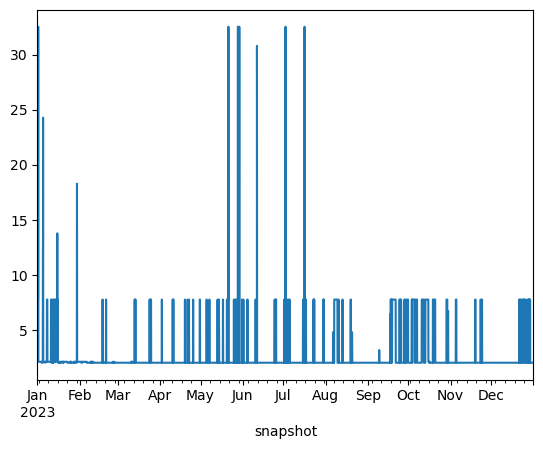

In [634]:
n.links_t.p0["PPA"].plot()

In [635]:
"Checking if Heat Load Matched the Heat Supply";
(-n.links_t.p1["pyrolysis"][0:24*7]) + (-n.links_t.p1["Heat_Exchanger_Rondo"][0:24*7]) + (-n.links_t.p1["Boiler_Skive"][0:24*7])+ (-n.links_t.p1["NG boiler"][0:24*7])

snapshot
2023-01-01 00:00:00    5.0
2023-01-01 01:00:00    5.0
2023-01-01 02:00:00    5.0
2023-01-01 03:00:00    5.0
2023-01-01 04:00:00    5.0
                      ... 
2023-01-07 19:00:00    5.0
2023-01-07 20:00:00    5.0
2023-01-07 21:00:00    5.0
2023-01-07 22:00:00    5.0
2023-01-07 23:00:00    5.0
Length: 168, dtype: float64

In [636]:
-n.links_t.p1["Heat_Exchanger_Rondo"]

snapshot
2023-01-01 00:00:00    0.0
2023-01-01 01:00:00    0.0
2023-01-01 02:00:00    0.0
2023-01-01 03:00:00    0.0
2023-01-01 04:00:00    0.0
                      ... 
2023-12-31 19:00:00    0.0
2023-12-31 20:00:00    0.0
2023-12-31 21:00:00    0.0
2023-12-31 22:00:00    0.0
2023-12-31 23:00:00    0.0
Name: Heat_Exchanger_Rondo, Length: 8760, dtype: float64

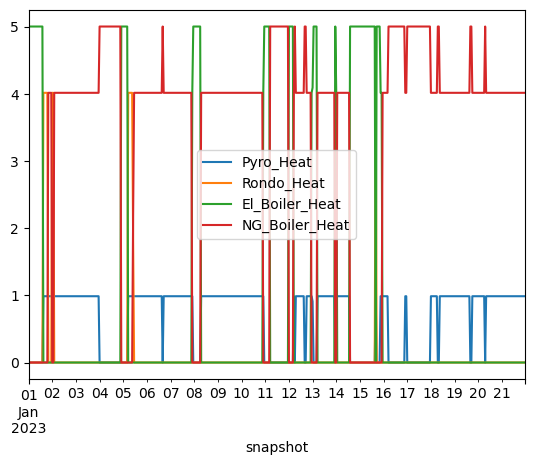

In [637]:
(-n.links_t.p1["pyrolysis"][0:24*7*3]).plot(label="Pyro_Heat")
(-n.links_t.p1["Heat_Exchanger_Rondo"][0:24*7*3]).plot(label="Rondo_Heat")
(-n.links_t.p1["Boiler_Skive"][0:24*7*3]).plot(label="El_Boiler_Heat")
(-n.links_t.p1["NG boiler"][0:24*7*3]).plot(label="NG_Boiler_Heat")
plt.legend()


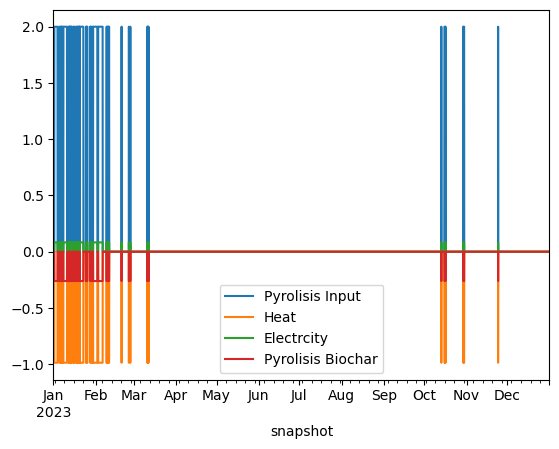

In [638]:
# Pyrolisis Input;
n.links_t.p0["pyrolysis"].plot(label="Pyrolisis Input")
# Pyrolisis Output:
n.links_t.p1["pyrolysis"].plot(label="Heat")
n.links_t.p2["pyrolysis"].plot(label="Electrcity")
n.links_t.p3["pyrolysis"].plot(label="Pyrolisis Biochar")

plt.legend()

<Axes: xlabel='snapshot'>

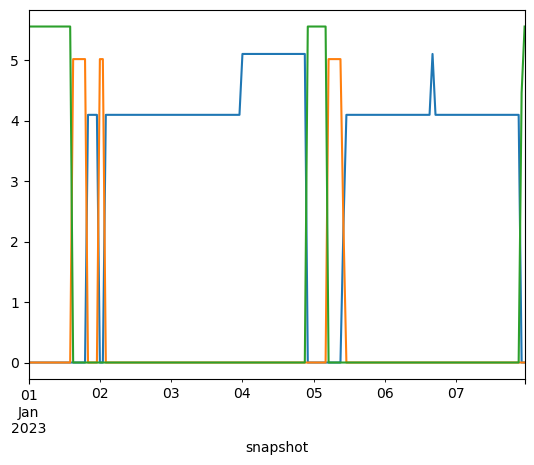

In [639]:
n.links_t.p0["NG boiler"][0:24*7].plot()
n.links_t.p0["Heat_Exchanger_Rondo"][0:24*7].plot()
n.links_t.p0["Boiler_Skive"][0:24*7].plot()

<Axes: xlabel='snapshot'>

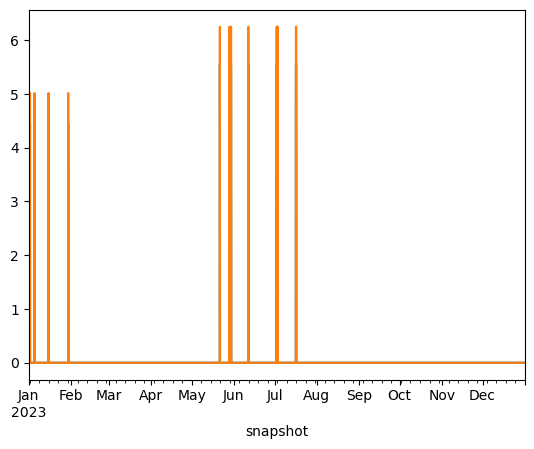

In [640]:
(n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"]*0.8).plot()
n.links_t.p0["Heat_Exchanger_Rondo"].plot()

In [641]:
n.links.p_nom_opt

Link
PPA                            32.531501
Imports                        84.000000
Exports                        84.000000
El_to_TES_Rondo                24.000000
TES_Rondo_to_Heat_Bus_Skive     7.000000
Heat_Exchanger_Rondo            6.250000
Boiler_Skive                   10.000000
NG boiler                       6.000000
pyrolysis                       2.000000
biochar sequestration           0.260593
Name: p_nom_opt, dtype: float64

In [621]:
n.stores.e_nom_opt

Store
Grid_Store                     125410.714616
Rondo_Concrete_Heat_Storage       100.000000
biochar sequestred                146.974514
Name: e_nom_opt, dtype: float64

In [622]:
n.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
Skive_Solar,EuroWind,PQ,,36.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,36.000000
Skive_Onshore_Wind,EuroWind,PQ,,54.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,54.000000
Grid_Generator,Grid_Import,PQ,,0.0,0.0,True,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,56.218042
NG grid,NG,PQ,,6.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,6.000000
pellets input,pellets,PQ,,0.0,0.0,True,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,2.000000


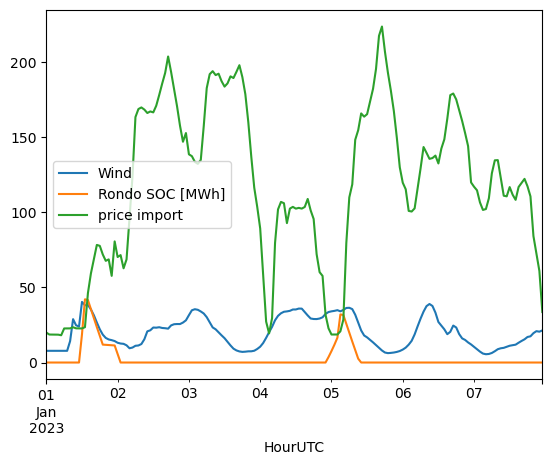

In [643]:
#(n.generators_t.p["Skive_Solar"])[0:24*7*2].plot(label ="Solar")
(n.generators_t.p["Skive_Onshore_Wind"])[0:24*7*1].plot(label ="Wind")
n.stores_t.e['Rondo_Concrete_Heat_Storage'][0:24*7*1].plot(label = "Rondo SOC [MWh]")
price_import23[0:24*7*1].plot(label = "price import")
plt.legend()

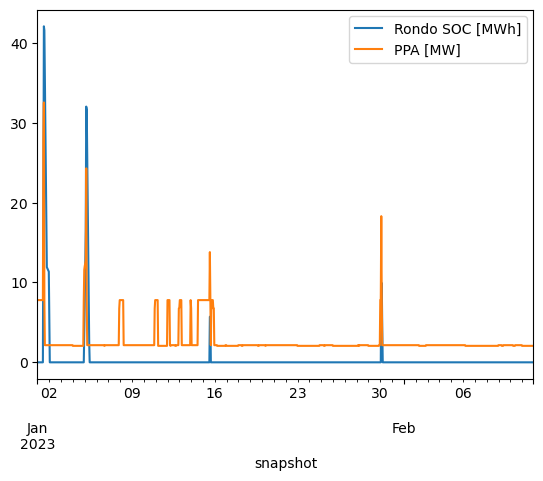

In [642]:
n.stores_t.e['Rondo_Concrete_Heat_Storage'][0:24*7*6].plot(label = "Rondo SOC [MWh]")
n.links_t.p0["PPA"][0:24*7*6].plot(label = "PPA [MW]")
plt.legend()

<Axes: xlabel='snapshot'>

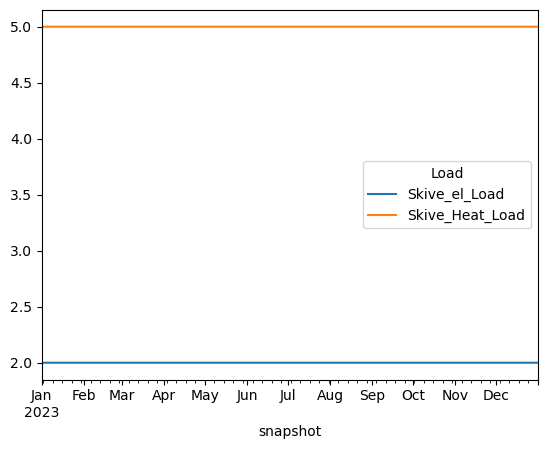

In [479]:
n.loads_t.p.plot()

<Axes: xlabel='snapshot'>

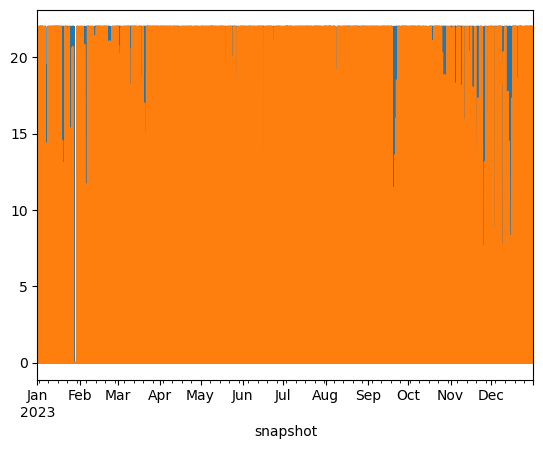

In [644]:
# Discharge power (positive when delivering electricity)
n.storage_units_t.p_dispatch["Skive_Battery"].plot()

# Charging power (positive when charging)
n.storage_units_t.p_store["Skive_Battery"].plot()


<Axes: xlabel='snapshot'>

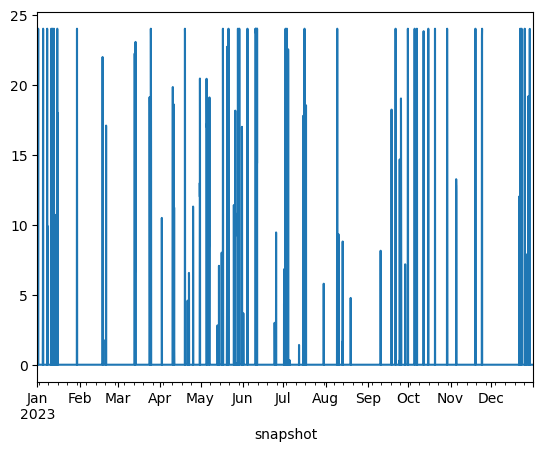

In [483]:
display(n.links_t.p0["El_to_TES_Rondo"].plot())

In [650]:
print("--- Objective Function ---")
print(n.model.objective)

--- Objective Function ---
Objective:
----------
LinearExpression: +0.0106 Generator-p[2023-01-01 00:00:00, Skive_Solar] + 1.429 Generator-p[2023-01-01 00:00:00, Skive_Onshore_Wind] + 5e-06 Generator-p[2023-01-01 00:00:00, Grid_Generator] ... +0 Link-p_nom[biochar sequestration] + 0 Store-e_nom[Grid_Store] + 0 Store-e_nom[biochar sequestred]
Sense: min
Value: -4462235.300265953


In [652]:
# This shows how many hours each snapshot represents in the optimization
print(n.snapshot_weightings)

                     objective  stores  generators
snapshot                                          
2023-01-01 00:00:00        1.0     1.0         1.0
2023-01-01 01:00:00        1.0     1.0         1.0
2023-01-01 02:00:00        1.0     1.0         1.0
2023-01-01 03:00:00        1.0     1.0         1.0
2023-01-01 04:00:00        1.0     1.0         1.0
...                        ...     ...         ...
2023-12-31 19:00:00        1.0     1.0         1.0
2023-12-31 20:00:00        1.0     1.0         1.0
2023-12-31 21:00:00        1.0     1.0         1.0
2023-12-31 22:00:00        1.0     1.0         1.0
2023-12-31 23:00:00        1.0     1.0         1.0

[8760 rows x 3 columns]


In [645]:
# 1. Show the entire mathematical summary
print(n.model)

# 2. Show the Objective Function specifically
print("--- Objective Function ---")
print(n.model.objective)

Linopy LP model

Variables:
----------
 * Generator-p_nom (Generator-ext)
 * Link-p_nom (Link-ext)
 * Store-e_nom (Store-ext)
 * Generator-p (snapshot, Generator)
 * Link-p (snapshot, Link)
 * Store-e (snapshot, Store)
 * StorageUnit-p_dispatch (snapshot, StorageUnit)
 * StorageUnit-p_store (snapshot, StorageUnit)
 * StorageUnit-state_of_charge (snapshot, StorageUnit)
 * Store-p (snapshot, Store)

Constraints:
------------
 * Generator-ext-p_nom-lower (Generator-ext)
 * Generator-ext-p_nom-upper (Generator-ext)
 * Link-ext-p_nom-lower (Link-ext)
 * Link-ext-p_nom-upper (Link-ext)
 * Store-ext-e_nom-lower (Store-ext)
 * Store-ext-e_nom-upper (Store-ext)
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Generator-ext-p-lower (snapshot, Generator-ext)
 * Generator-ext-p-upper (snapshot, Generator-ext)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Link-ext-p-lower (snapshot, Link-ext)
 * Link-ext-

In [649]:
n.model.constraints["Generator-ext-p_nom-lower"]
n.model.constraints["StorageUnit-fix-state_of_charge-upper"]

Constraint `StorageUnit-fix-state_of_charge-upper` [snapshot: 8760, StorageUnit-fix: 1]:
----------------------------------------------------------------------------------------
[2023-01-01 00:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 00:00:00, Skive_Battery] ≤ 88.0
[2023-01-01 01:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 01:00:00, Skive_Battery] ≤ 88.0
[2023-01-01 02:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 02:00:00, Skive_Battery] ≤ 88.0
[2023-01-01 03:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 03:00:00, Skive_Battery] ≤ 88.0
[2023-01-01 04:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 04:00:00, Skive_Battery] ≤ 88.0
[2023-01-01 05:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 05:00:00, Skive_Battery] ≤ 88.0
[2023-01-01 06:00:00, Skive_Battery]: +1 StorageUnit-state_of_charge[2023-01-01 06:00:00, Skive_Battery] ≤ 88.0
		...
[2023-12-31 17:00:00, Skive_Batt

In [501]:
# Draw the network
pypsatopo.generate(n)

[ERR] The tool 'dot' is not installed or could not be found (please visit https://graphviz.org/download to download and install it)!


-1